In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("Customers.csv")
data.head(5)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
Data = data[["Annual Income (k$)","Spending Score (1-100)"]]
Data.sample(5)

,Annual Income (k$),Spending Score (1-100)
118,67,43
136,73,7
71,49,42
135,73,88
112,64,42


In [4]:
Data = Data.rename(columns={'Annual Income (k$)':'Income','Spending Score (1-100)':'Score'})
Data.sample(5)

,Income,Score
13,20,77
22,25,5
136,73,7
187,101,68
184,99,39


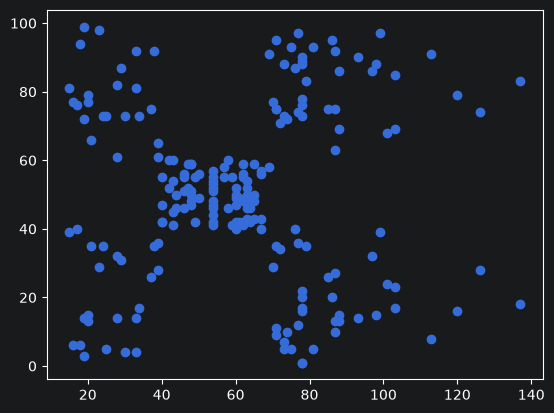

In [5]:
import matplotlib.pyplot as plt
plt.scatter(Data.Income,Data.Score)

In [6]:
from sklearn.cluster import KMeans
k_values = [1,2,3,4,5,6,7,8,9,10]
wcss_error = []
for i in k_values:
    model = KMeans(n_clusters=i)
    model.fit(Data[['Income','Score']])
    wcss_error.append(model.inertia_)


In [7]:
wcss_error

[269981.28,
 183653.3289473684,
 106348.37306211119,
 73880.64496247195,
 67789.2964458247,
 37455.984555160285,
 30566.451130251862,
 26102.943894611133,
 23996.53495097075,
 20067.316562465174]

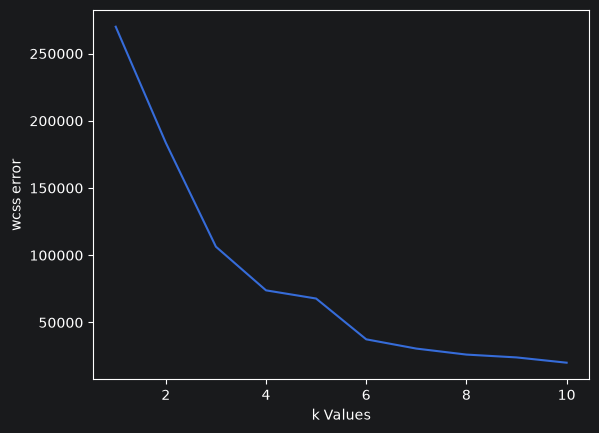

In [8]:
plt.xlabel('k Values')
plt.ylabel('wcss error')
plt.plot(k_values,wcss_error)

In [9]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=5)
pred = model.fit_predict(Data[['Income','Score']])

In [10]:
pred

array([3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 2,
       3, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1], dtype=int32)

In [11]:
Data['cluster'] = pred
Data.head(5)

,Income,Score,cluster
0,15,39,3
1,15,81,4
2,16,6,3
3,16,77,4
4,17,40,3


In [12]:
cluster0 = Data[Data['cluster']==0]
cluster1 = Data[Data['cluster']==1]
cluster2 = Data[Data['cluster']==2]
cluster3 = Data[Data['cluster']==3]
cluster4 = Data[Data['cluster']==4]

In [13]:
cluster0

,Income,Score,cluster
124,70,29,0
128,71,11,0
130,71,9,0
134,73,5,0
136,73,7,0
138,74,10,0
140,75,5,0
144,77,12,0
146,77,36,0
148,78,22,0


In [14]:
cluster1

,Income,Score,cluster
123,69,91,1
125,70,77,1
127,71,95,1
129,71,75,1
131,71,75,1
133,72,71,1
135,73,88,1
137,73,73,1
139,74,72,1
141,75,93,1


In [15]:
cluster2

,Income,Score,cluster
43,39,61,2
46,40,55,2
47,40,47,2
48,40,42,2
49,40,42,2
...,...,...,...
121,67,40,2
122,69,58,2
126,71,35,2
132,72,34,2


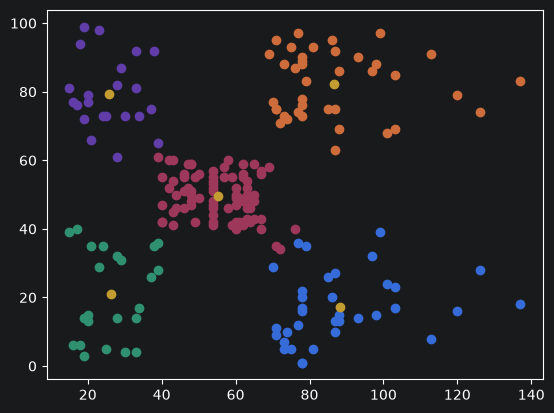

In [16]:
plt.scatter(cluster0['Income'],cluster0['Score'])
plt.scatter(cluster1['Income'],cluster1['Score'])
plt.scatter(cluster2['Income'],cluster2['Score'])
plt.scatter(cluster3['Income'],cluster3['Score'])
plt.scatter(cluster4['Income'],cluster4['Score'])
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1])

In [61]:
model.cluster_centers_

array([[55.2962963 , 49.51851852],
       [88.2       , 17.11428571],
       [25.72727273, 79.36363636],
       [86.53846154, 82.12820513],
       [26.30434783, 20.91304348]])

In [62]:
model.cluster_centers_

array([[55.2962963 , 49.51851852],
       [88.2       , 17.11428571],
       [25.72727273, 79.36363636],
       [86.53846154, 82.12820513],
       [26.30434783, 20.91304348]])